In [14]:
import numpy as np
import h5py
import re

In [ ]:
file_name = "data/ns_ETD_mrGSAV_MS2_b_bursting_50_1_vs.h5"; nu = 1/50

n_startup = 1

with h5py.File(file_name, "r") as f:
    group_names = list(f.keys())
    print("Groups found:", group_names)

    # Parse t_start, t_end from group names like "t_0_10"
    intervals = []
    for name in group_names:
        match = re.match(r"t_([\d.]+)_([\d.]+)", name)
        if match:
            t_start = float(match.group(1))
            t_end = float(match.group(2))
            intervals.append((t_start, t_end, name))

    # Sort by t_start
    intervals.sort(key=lambda x: x[0])
    print("Sorted intervals:", [(name, t_start, t_end) for t_start, t_end, name in intervals])

    # --- Load trajectory data (all time steps) with boundary dedup ---
    traj_keys = ["tn", "tau", "q", "Energy", "Enstrophy", "Palinstrophy", "Mx", "CPU_time"]
    traj_data = {k: [] for k in traj_keys}

    # --- Load snapshot data (integer-time snapshots) with boundary dedup ---
    snap_data = {"tn_s": [], "Omega": []}

    for i, (t_start, t_end, name) in enumerate(intervals):
        grp = f[name]

        # Unified boundary check based on tn; also skip startup transient points
        n_skip = 0
        if i > 0 and len(traj_data["tn"]) > 0:
            prev_tn_last = traj_data["tn"][-1][-1]
            curr_tn_first = grp["tn"][0]
            if np.isclose(prev_tn_last, curr_tn_first) or curr_tn_first <= prev_tn_last:
                n_skip = 1 + n_startup

        # Trajectory data
        for key in traj_keys:
            arr = grp[key][()]
            if n_skip > 0:
                arr = arr[n_skip:]
            traj_data[key].append(arr)

        # Snapshot data
        tn_s_arr = grp["tn_s"][()]
        Omega_arr = grp["Omega"][()]
        if i > 0 and len(snap_data["tn_s"]) > 0:
            prev_tn_s_last = snap_data["tn_s"][-1][-1]
            if np.isclose(prev_tn_s_last, tn_s_arr[0]):
                tn_s_arr = tn_s_arr[1:]
                Omega_arr = Omega_arr[1:]
        snap_data["tn_s"].append(tn_s_arr)
        snap_data["Omega"].append(Omega_arr)

    # Concatenate
    for key in traj_keys:
        exec(f"{key} = np.concatenate(traj_data['{key}'])")
    tn_s = np.concatenate(snap_data["tn_s"])
    Omega = np.concatenate(snap_data["Omega"], axis=0)

print("\n--- Concatenated arrays ---")
print("CPU_time:", CPU_time.shape)
print("Energy:", Energy.shape)
print("Enstrophy:", Enstrophy.shape)
print("Mx:", Mx.shape)
print("Omega:", Omega.shape)
print("Palinstrophy:", Palinstrophy.shape)
print("q:", q.shape)
print("tn:", tn.shape)
print("tn_s:", tn_s.shape)
print("tau:", tau.shape)

Groups found: ['t_0_1000.0002116106696']
Sorted intervals: [('t_0_1000.0002116106696', 0.0, 1000.0002116106696)]

--- Concatenated arrays ---
CPU_time: (3340677,)
Energy: (3340677,)
Enstrophy: (3340677,)
Mx: (3340677,)
Omega: (1001, 64, 64)
Palinstrophy: (3340677,)
q: (3340677,)
tn: (3340677,)
tn_s: (1001,)
tau: (3340677,)


In [16]:
x = np.linspace(0, np.pi*2, Omega.shape[2]+1); hx = np.diff(x)[0]
y = np.linspace(0, np.pi*2, Omega.shape[1]+1); hy = np.diff(y)[0]
X,Y = np.meshgrid(x, y)

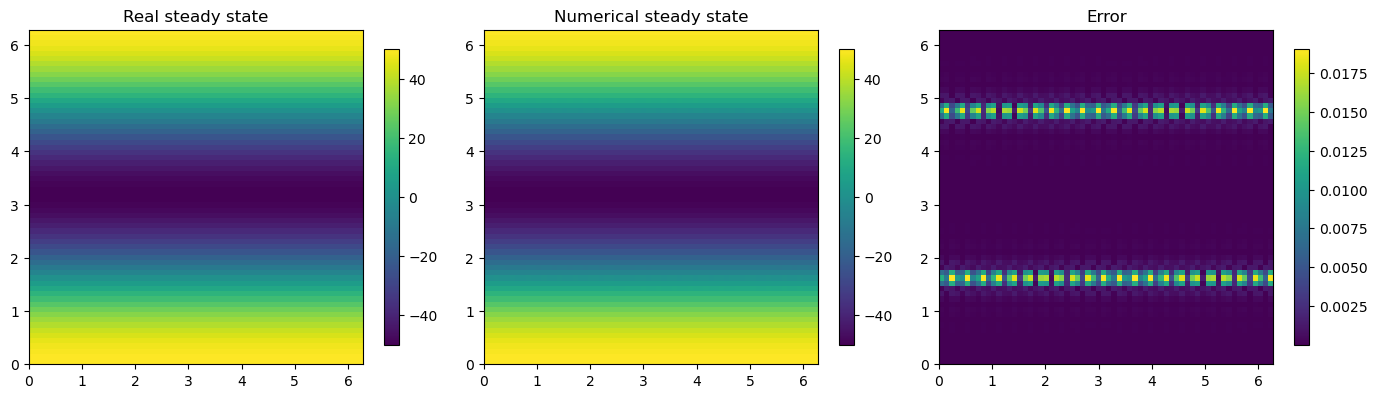

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

omega_true = np.cos(Y[:-1, :-1]) / nu
omega_num = Omega[-1]

omega_err  = np.abs(np.cos(Y[:-1, :-1]) / nu - Omega[-1])/10

titles = ["Real steady state", "Numerical steady state", "Error"]
data   = [omega_true, omega_num, omega_err]

for ax, d, title in zip(axes, data, titles):
    im = ax.pcolormesh(X, Y, d, shading="auto")
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

In [27]:
np.linalg.norm(np.cos(Y[:-1, :-1]) / nu - Omega[-1])/np.linalg.norm(np.cos(Y[:-1, :-1]) / nu)/10

np.float64(9.017621164102602e-05)

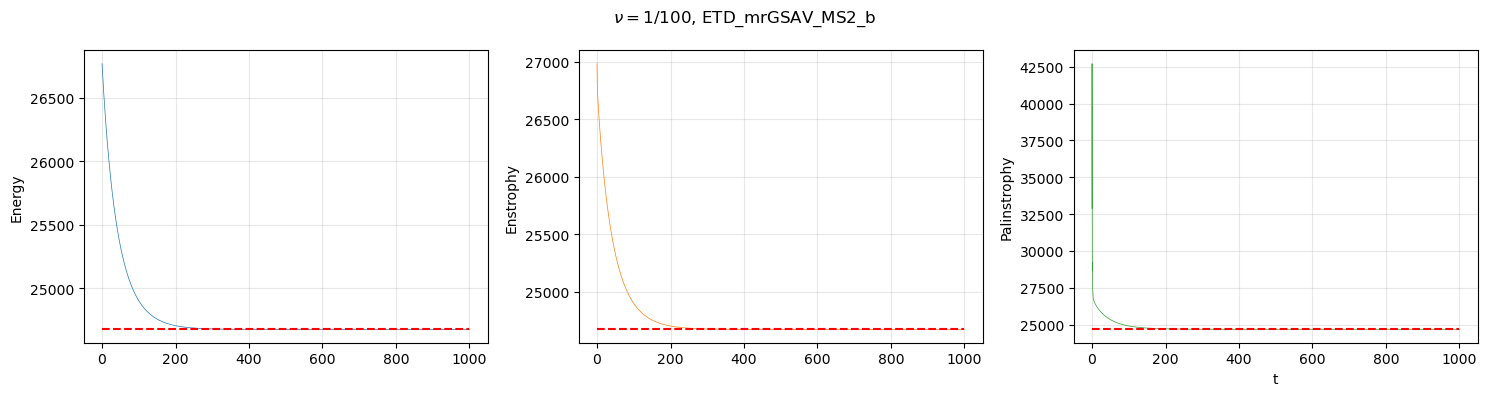

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

axes[0].plot(tn[::5000], Energy[::5000], linewidth=0.5)
axes[0].hlines(np.pi**2/nu**2, tn[0], tn[-1], colors="red", linestyles="dashed")
axes[0].set_ylabel("Energy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(tn[::5000], Enstrophy[::5000], linewidth=0.5, color="tab:orange")
axes[1].hlines(np.pi**2/nu**2, tn[0], tn[-1], colors="red", linestyles="dashed")
axes[1].set_ylabel("Enstrophy")
axes[1].grid(True, alpha=0.3)

axes[2].plot(tn[::5000], Palinstrophy[::5000], linewidth=0.5, color="tab:green")
axes[2].hlines(np.pi**2/nu**2, tn[0], tn[-1], colors="red", linestyles="dashed")
axes[2].set_ylabel("Palinstrophy")
axes[2].set_xlabel("t")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"$\nu=1/100$, ETD_mrGSAV_MS2_b")
plt.tight_layout()
plt.show()


In [32]:
print("Energy: {}, Enstrophy: {}, Palinstrophy: {}".format(Energy[-1], Enstrophy[-1], Palinstrophy[-1]))


Energy: 24674.01176686038, Enstrophy: 24674.031789883855, Palinstrophy: 24684.15459544043


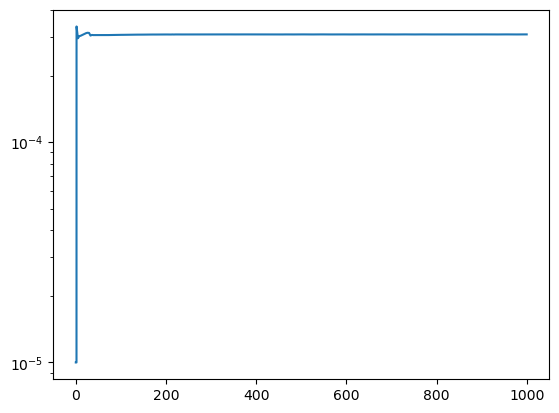

In [24]:
plt.plot(tn[::10000 ], tau[::10000])
plt.yscale("log")